# Turnaround Tuesday — a quantitative teardown 🔬
### The down-Monday-Tuesday Welch/HAC split · a 20-seed random-pair placebo · the five-weekday-pair specificity test · a crisis-window robustness cut · the pre/post-2000 era contrast · an honest cost sweep · a 20-seed synthetic null

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Monday-specific%3F: Confirmed](https://img.shields.io/badge/Monday--specific%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a down Monday predicts a Tuesday bounce** — is a conditional claim, distinct from every day-of-week *level* claim already on this desk (studies 90 and 224). The job here is to measure it honestly, rule out the boring explanation (generic reversal wearing a calendar costume), and then ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** SPY daily raw OHLC + adjusted (total-return) close, 1993-01-29 → 2026-06-30, yfinance, cached. No hardcoded event calendar — "Monday"/"Tuesday" are `.dayofweek` facts. No survivorship (single continuous index series). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `bf55c945be2e`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turnaround_tuesday import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY = data.load_real()
    DF = st.day_frame(SPY["AdjClose"])
    PAIRS = st.monday_tuesday_pairs(DF)
else:
    SPY = DF = PAIRS = None
print("real cache present:", HAVE_REAL, "| Monday->Tuesday pairs:",
      (0 if PAIRS is None else len(PAIRS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-29', 'end': '2026-06-30', 'n_pairs': 1567, 'n_down': 684, 'n_up': 883, 'n_uncond_tue': 1728, 'n_allday': 8410, 'cond_bps': 21.34, 'up_bps': -2.21, 'uncond_tue_bps': 7.09, 'allday_bps': 4.77, 'welch_uncond': 2.38, 'welch_up': 3.85, 'welch_allday': 3.04, 'nw_allday_t': 3.19, 'nw_allday_coef': 18.04, 'nw_tue_t': 3.8, 'nw_tue_coef': 23.6, 'hit': 387, 'hit_pct': 56.6, 'wilson': (52.8, 60.2), 'placebo_p': 5e-05, 'placebo_mean': 8.05, 'placebo_sd': 3.27, 'placebo_draws': 20000, 'weekday_pairs': {'Mon->Tue': (1567, 21.34, -2.21, 3.85), 'Tue->Wed': (1710, 7.59, 4.2, 0.61), 'Wed->Thu': (1675, 0.17, 2.38, -0.38), 'Thu->Fri': (1634, 5.13, 0.63, 0.81), 'Fri->Mon': (1521, 7.67, 5.68, 0.29)}, 'other_pooled_n': 2987, 'other_pooled_down_bps': 5.15, 'other_pooled_up_bps': 3.19, 'other_pooled_t': 0.66, 'excrisis_n': 652, 'excrisis_bps': 14.81, 'excrisis_t': 3.14, 'era_split': '2000-01-01', 'era_early_bps': 19.91, 'era_early_n': 135, 'era_early_t': 0.91, 'era_late_bps': 21.69, 'era_late_n': 549, 'era_late_t': 2.2, 'era_diff_t': 0.15, 'events_per_year': 20.5, 'timer_5_gross': 21.3, 'timer_5_net': 11.3, 'timer_5_ann': 2.32, 'timer_5_t': 2.14, 'timer_5_sharpe': 0.37, 'timer_5_worst': -4.58, 'timer_10_gross': 21.3, 'timer_10_net': 1.3, 'timer_10_ann': 0.27, 'timer_10_t': 0.25, 'timer_10_sharpe': 0.04, 'timer_10_worst': -4.68, 'syn_null_mean': -0.03, 'syn_null_sd': 0.93, 'syn_null_fire': 0, 'syn_planted_t': 4.7, 'fp_spy': 'bf55c945be2e'}


real cache present: True | Monday->Tuesday pairs: 1567


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | down-Monday Tuesday **+21.34 bps** vs unconditional +7.09: Welch **t = 2.38** (vs unconditional) / **3.85** (vs up-Monday), NW **t = 3.19-3.80**, placebo **p = 0.00005**, Monday-specific (pooled other-weekday t = 0.66) |
| **Tradability** | `FRAGILE` | net of 5 bps: t = 2.14, Sharpe 0.37; net of 10 bps: t = 0.25, Sharpe 0.04 |
| **Monday-specific?** | `CONFIRMED` | Mon→Tue t = 3.85; pooled other four weekday pairs t = 0.66 |

> 💡 In plain words: the pattern is genuine and specifically tied to Monday, not a relabelled version of generic reversal — but the tradable edge is thin enough that a single extra basis point of cost kills it.

## 1 · The claim, steelmanned

Let $r_t$ be the SPY close-to-close total return on session $t$, $M_t$ a Monday session with $r_{M_t} < 0$ (a "down Monday"), and $T_{t+1}$ the immediately following Tuesday session (excluded if a Monday market holiday breaks the adjacency). The claims:

- **H₁ (bounce).** $E[r_{T} \mid r_{M} < 0] \gg E[r_{T}]$ — a down Monday predicts an above-average Tuesday.
- **H₂ (asymmetry).** The effect is a genuine *conditional* relationship, not just "Tuesday is good": Tuesdays after an *up* Monday should NOT show the same bounce.
- **H₃ (specificity).** The pattern is tied to *Monday* specifically — not a generic "any down day bounces the next session" reversal effect relabelled with a calendar hook.
- **H₄ (capture).** A literal SPY timer (buy the down-Monday close, sell the Tuesday close) banks the edge net of realistic costs.

We find **H₁ strongly supported** (Welch t up to +3.85, NW t up to +3.80, placebo p = 0.00005), **H₂ supported** (up-Monday Tuesdays are flat-to-negative, -2.21 bps), **H₃ supported** (pooled other-weekday t = 0.66), **H₄ marginal** (t = 2.14 at 5 bps, t = 0.25 at 10 bps).

## 2 · So what? — inference design

Down-Monday events are **weekly, non-overlapping** — the planned primary is a **Welch t** on the group split, run three ways (vs unconditional Tuesday, vs up-Monday Tuesday, vs all trading days) so a single comparison group can't drive the conclusion. Because the daily return series is serially correlated, we cross-check with a **Newey-West (5-lag) t** on the down-Monday-Tuesday dummy regression — the slope *is* the mean gap. The hit rate carries a **Wilson interval**, the placebo reshuffles the down-Monday label among Tuesdays **20,000 times (20 seeds × 1,000)**, and the era split (2000-01-01, named ex ante in the brief) is tested as a **difference**, not eyeballed.

## 3 · How we'd know — the protocol

- **Pairing.** 1,567 Monday→Tuesday consecutive-session pairs 1993-01-29 → 2026-06-30, 684 with a down Monday, 883 with an up Monday (holiday-broken weeks correctly excluded).
- **Headline.** Welch t (three comparisons) + NW(5) t (two dummy regressions) + Wilson hit rate + 20-seed placebo.
- **Specificity.** The identical down-day → next-day split on all five weekday pairs; the other four pooled and Welch-t'd against Mon→Tue.
- **Robustness.** Drop the 2008-09 GFC and 2020-03 COVID crash windows entirely.
- **Era.** Pre/post-2000, within-era Welch t's + a Welch t of the difference.
- **Execution (timer).** Enter SPY at the down Monday's own close (the flag is knowable at that instant — it *is* that close, zero look-ahead), exit the Tuesday close; 2 × one-way cost × NAV per event; long-only, no borrow.
- **Control.** Synthetic i.i.d.-drift tape, planted-bounce knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo

Welch t on Tuesday returns (three comparisons), NW t on two dummy regressions, and the random-pair null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

down-Monday Tuesday +21.34 bps (n=684)  vs  unconditional +7.09 bps (n=1728)  vs  up-Monday -2.21 bps (n=883)
Welch t = +2.38 (vs uncond) / +3.85 (vs up-Monday) / +3.04 (vs all days)
NW(5) t vs all days = +3.19   NW(5) t vs Tuesdays = +3.80
hit 387/684 = 56.6%  Wilson [52.8%, 60.2%]


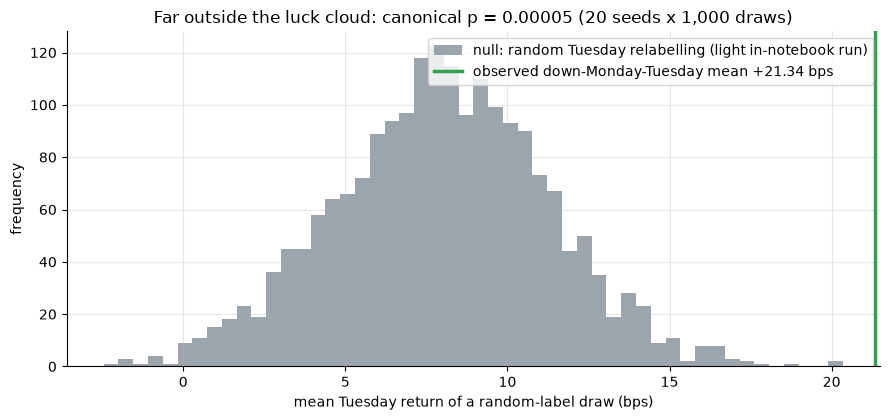

canonical placebo (results.md): mean +8.05 bps, sd 3.27, p = 0.00005


In [2]:
if HAVE_REAL:
    h = st.headline_stats(DF, PAIRS)
    print(f"down-Monday Tuesday {h['cond_bps']:+.2f} bps (n={h['n_down']})  vs  "
          f"unconditional {h['uncond_tue_bps']:+.2f} bps (n={h['n_uncond_tue']})  vs  "
          f"up-Monday {h['up_bps']:+.2f} bps (n={h['n_up']})")
    print(f"Welch t = {h['welch_t_vs_uncond']:+.2f} (vs uncond) / "
          f"{h['welch_t_vs_up']:+.2f} (vs up-Monday) / {h['welch_t_vs_allday']:+.2f} (vs all days)")
    print(f"NW(5) t vs all days = {h['nw_t_vs_allday']:+.2f}   NW(5) t vs Tuesdays = {h['nw_t_vs_uncond']:+.2f}")
    print(f"hit {h['hit']}/{h['n_down']} = {h['hit_rate']*100:.1f}%  "
          f"Wilson [{h['hit_lo']*100:.1f}%, {h['hit_hi']*100:.1f}%]")
    pl = st.placebo_pvalue(PAIRS, n_draws_per_seed=500, n_seeds=4)
    obs, draws = pl['obs']*1e4, pl['draws']*1e4
else:
    obs = R['cond_bps']
    rng = np.random.default_rng(642)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random Tuesday relabelling (light in-notebook run)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed down-Monday-Tuesday mean {obs:+.2f} bps')
ax.set_xlabel('mean Tuesday return of a random-label draw (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"Far outside the luck cloud: canonical p = {R['placebo_p']:.5f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.2f} bps, "
      f"sd {R['placebo_sd']:.2f}, p = {R['placebo_p']:.5f}")

> 💡 In plain words: the observed **+21.34 bps** sits several placebo-sigmas above the null's center (+8.05 ± 3.27 bps); **p = 0.00005**. With Welch t up to **3.85** and NW t up to **3.80**, H₁ clears the desk bar several separate ways.

### 4b · The specificity test — Monday, or generic reversal?

The same down-day → next-day split, run on all five weekday pairs. If turnaround Tuesday were just short-horizon reversal (Jegadeesh 1990, Lehmann 1990) relabelled with a calendar hook, every pair should look roughly the same.

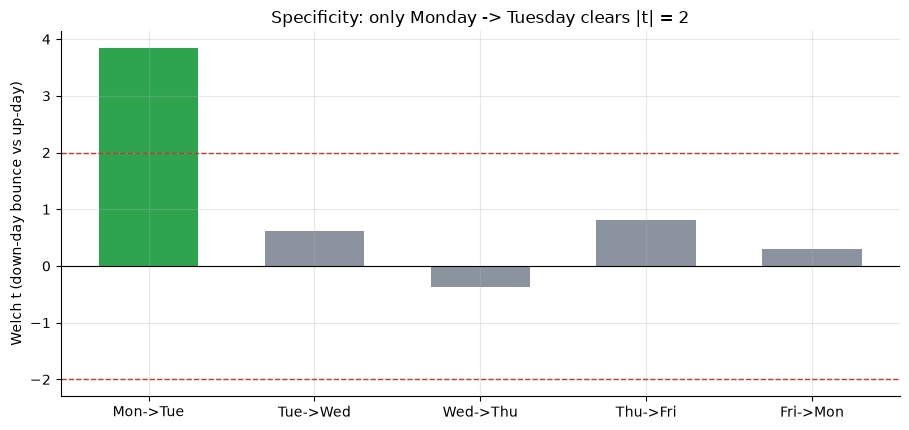

{'Mon->Tue': 3.85, 'Tue->Wed': 0.61, 'Wed->Thu': -0.38, 'Thu->Fri': 0.81, 'Fri->Mon': 0.29}  | pooled other-4: 0.66


In [3]:
if HAVE_REAL:
    wp = st.weekday_pair_stats(DF)
    labels = list(wp.index); ts = list(wp['welch_t'])
    oc = st.other_weekday_check(DF)
    other_t = oc['welch_t']
else:
    labels = list(R['weekday_pairs']); ts = [R['weekday_pairs'][p][3] for p in labels]
    other_t = R['other_pooled_t']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [GREEN if p=='Mon->Tue' else GREY for p in labels]
ax.bar(labels, ts, color=cols, width=.6)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (down-day bounce vs up-day)')
ax.set_title('Specificity: only Monday -> Tuesday clears |t| = 2')
plt.tight_layout(); plt.show()
print({l: round(t,2) for l,t in zip(labels, ts)}, ' | pooled other-4:', round(other_t,2))

> 💡 In plain words: pooled across the other four weekday pairs (n=2,987 down-day events), the "bounce" is **t = 0.66** — nothing. Only Mon→Tue clears the bar (t = 3.85). H₃ holds: this is not generic reversal wearing a calendar costume; it is specifically about the weekend-adjacent Monday close.

### 4c · Robustness — not a crisis-day artifact, and no decay

Drop the two loudest macro windows on the tape; then split pre/post-2000.

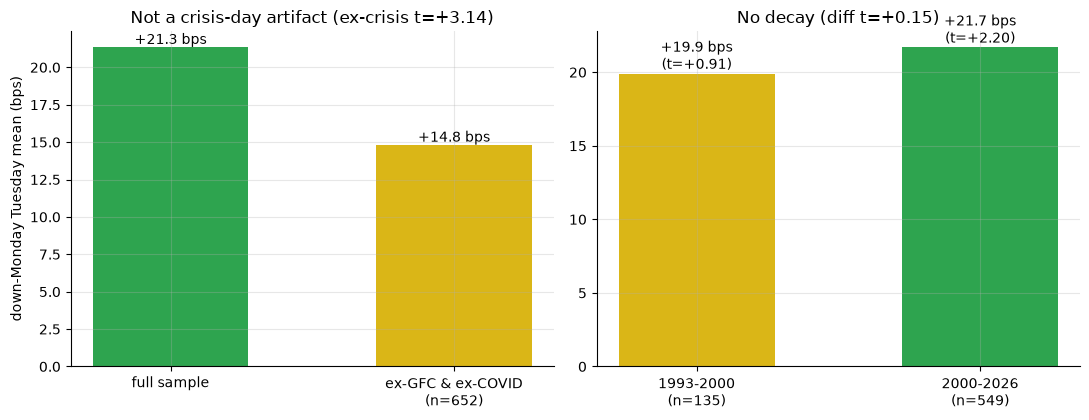

ex-crisis +14.81 bps (t=+3.14, n=652)
era: early +19.91 (t=+0.91)  late +21.69 (t=+2.20)  diff t=+0.15


In [4]:
if HAVE_REAL:
    ex = st.excl_crisis_check(PAIRS)
    ex_bps, ex_t, ex_n = ex['mean_bps'], ex['welch_t'], ex['n']
    ec = st.era_contrast(DF, PAIRS, data.ERA_SPLIT)
    e, l = ec['early_bps'], ec['late_bps']
    et, lt, dt = ec['welch_t_early'], ec['welch_t_late'], ec['welch_t_diff']
else:
    ex_bps, ex_t, ex_n = R['excrisis_bps'], R['excrisis_t'], R['excrisis_n']
    e, l = R['era_early_bps'], R['era_late_bps']
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['full sample','ex-GFC & ex-COVID\n(n={})'.format(ex_n)], [R['cond_bps'], ex_bps],
       color=[GREEN, AMBER], width=.55)
for i,v in enumerate([R['cond_bps'], ex_bps]): a1.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom')
a1.set_ylabel('down-Monday Tuesday mean (bps)')
a1.set_title(f'Not a crisis-day artifact (ex-crisis t={ex_t:+.2f})')
a2.bar(['1993-2000\n(n={})'.format(R['era_early_n']),'2000-2026\n(n={})'.format(R['era_late_n'])],
       [e, l], color=[AMBER, GREEN], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    a2.annotate(f'{v:+.1f} bps\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
a2.set_title(f'No decay (diff t={dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'ex-crisis {ex_bps:+.2f} bps (t={ex_t:+.2f}, n={ex_n})')
print(f'era: early {e:+.2f} (t={et:+.2f})  late {l:+.2f} (t={lt:+.2f})  diff t={dt:+.2f}')

> 💡 In plain words: with the 2008-09 GFC and 2020-03 COVID crash windows dropped entirely, the effect shrinks but survives (**+14.81 bps**, t = +3.14, n = 652) — it isn't a handful of huge macro days dragging the mean. And there is no decay across the 2000 split: the pre-2000 slice alone is underpowered (n = 135, t = +0.91) but the post-2000 slice, with four times the events, clears the bar on its own (t = +2.20); the difference test finds nothing (t = +0.15).

### 4d · The timer — honest cost sweep

Enter at the down Monday's own close (zero look-ahead — the flag *is* that close), exit the Tuesday close, pay 2 × one-way cost per event.

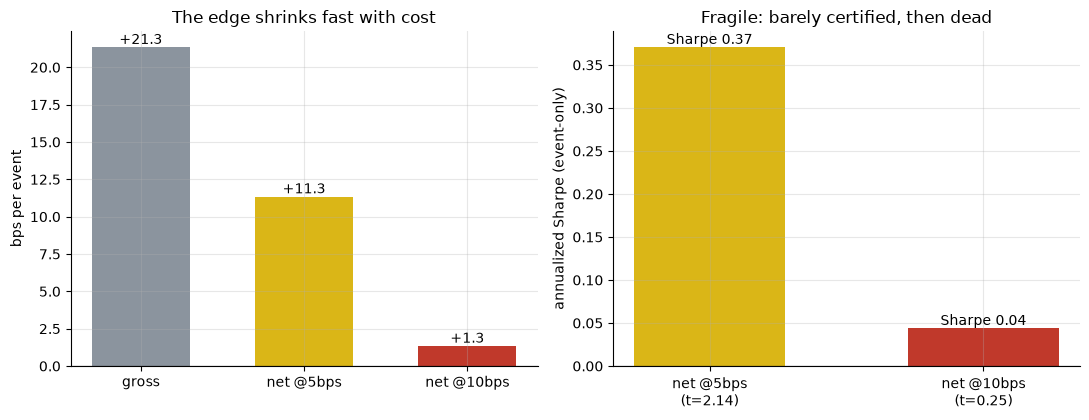

gross +21.3 -> net +11.3 (t=+2.14, Sharpe 0.37) / +1.3 bps (t=+0.25, Sharpe 0.04)


In [5]:
if HAVE_REAL:
    years = (DF.index.max() - DF.index.min()).days / 365.25
    tm5 = st.timer_stats(PAIRS, cost_bps=5.0, years=years)
    tm10 = st.timer_stats(PAIRS, cost_bps=10.0, years=years)
    g, n5, n10 = tm5['gross_bps'], tm5['net_bps'], tm10['net_bps']
    t5, t10 = tm5['t_net'], tm10['t_net']
    sh5, sh10 = tm5['sharpe_net'], tm10['sharpe_net']
else:
    g = R['timer_5_gross']; n5, n10 = R['timer_5_net'], R['timer_10_net']
    t5, t10 = R['timer_5_t'], R['timer_10_t']
    sh5, sh10 = R['timer_5_sharpe'], R['timer_10_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('bps per event')
a1.set_title('The edge shrinks fast with cost')
a2.bar(['net @5bps\n(t={:.2f})'.format(t5),'net @10bps\n(t={:.2f})'.format(t10)],
       [sh5, sh10], color=[AMBER, RED], width=.55)
for i,v in enumerate([sh5, sh10]): a2.annotate(f'Sharpe {v:.2f}',(i,v),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('annualized Sharpe (event-only)')
a2.set_title('Fragile: barely certified, then dead')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f} -> net {n5:+.1f} (t={t5:+.2f}, Sharpe {sh5:.2f}) / '
      f'{n10:+.1f} bps (t={t10:+.2f}, Sharpe {sh10:.2f})')

> 💡 In plain words: +11.3 bps net per event at 5 bps cost, ~+2.3%/yr from ~20 events a year — *barely* certifiable (t = 2.14, the bar is 2). At 10 bps the whole thing collapses to +1.3 bps at t = 0.25 — statistically nothing. Structurally: the position is only on ≈8% of trading days, so the total dollars at stake are thin, and a single worst event (-4.6% to -4.7%) can erase years of net edge either way. H₄ marginal at best; **Tradability = FRAGILE**.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic i.i.d.-drift daily-return tape, TUNABLE planted down-Monday → Tuesday bounce. The null (bounce = 0) is checked over **20 seeds** — never a single stream.

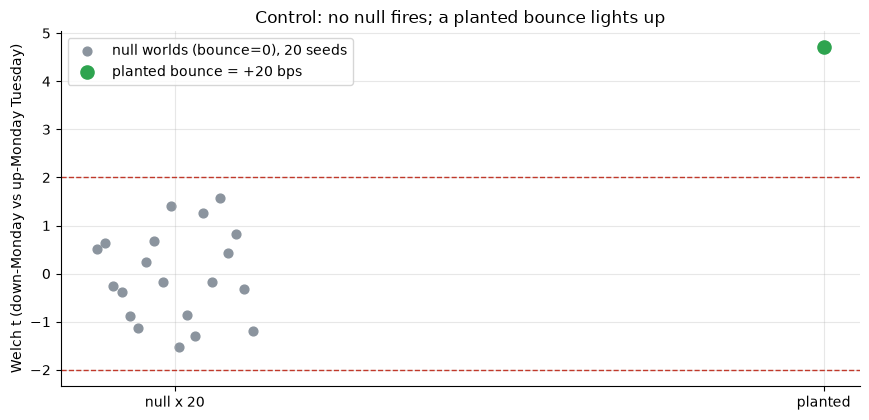

null: mean t = -0.03 (sd 0.93), |t|>=2 in 0/20 seeds  |  planted t = +4.70


In [6]:
null_ts = []
for s_ in range(20):
    close = data.synthetic_world(bounce=0.0, seed=642 + s_)
    null_ts.append(st.synthetic_detect(close)['welch_t'])
null_ts = np.asarray(null_ts)
close = data.synthetic_world(bounce=0.0020, seed=642)
planted_t = st.synthetic_detect(close)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (bounce=0), 20 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=90, zorder=5,
           label='planted bounce = +20 bps')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (down-Monday vs up-Monday Tuesday)')
ax.set_title('Control: no null fires; a planted bounce lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.03 (sd 0.93) and **never** crosses the bar; a planted 20 bp bounce reads t = 4.70. The machinery is unbiased — the real-tape t up to 3.85 is the genuine article. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `REAL`** — down-Monday Tuesday **+21.34 bps** vs unconditional +7.09 (Welch t = 2.38) and vs up-Monday Tuesday -2.21 (Welch t = 3.85); NW t = 3.19/3.80; placebo p = 0.00005; robust ex-crisis (t = 3.14); no decay (diff t = 0.15); genuinely Monday-specific (pooled other-weekday t = 0.66).
- **Tradability `FRAGILE`** — net of 5 bps: t = 2.14, Sharpe 0.37, ~+2.32%/yr; net of 10 bps: t = 0.25, Sharpe 0.04, ~+0.27%/yr — barely certified, then dead, on a position only on ≈8% of trading days.
- **Monday-specific? `CONFIRMED`** — only Mon→Tue clears |t| = 2 among all five weekday down-day → next-day pairs; the pooled other four are t = 0.66.

## 6 · Going further

- **Why Monday specifically?** The most plausible mechanism: two non-trading days (a weekend) let news, order flow and sentiment accumulate uninterrupted, so a red Monday can overshoot the information it's reacting to more than a normal single-session move — leaving more of it to mean-revert by the next close. That's a testable hypothesis for a follow-up study (does the size of the bounce scale with the size of the Monday drop, or with weekend news flow/gap size specifically?).
- **Why the edge doesn't scale:** the position is on for one session, roughly once a week, and the whole edge lives in ~20 bps of margin — a level realistic institutional SPY execution costs can eat easily, especially once market impact and adverse selection (everyone else also knows Monday closed red) are added.
- **Dedup map:** [224-monday-effect](../../224-monday-effect/) (is Monday itself negative? no — `NONE`), [90-weekend](../../90-weekend/) (the unconditional weekday level table, which names "turnaround Tuesday" but never conditions on Monday's sign), [116-power-hour](../../116-power-hour/) (an intraday continuation/reversal claim on a different clock).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*